In [15]:
import pandas as pd
import io
import matplotlib.pyplot as plt
import numpy as np
import re

import pandas as pd


In [16]:

def parse_log_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

    data = {}
    
    # --- 1. Extract Metadata (Model, Loss, Features) ---
    # We look for the "Final Aggregated Results" block
    pattern = r"Final Aggregated Results.*?={40}"
    agg_block_match = re.search(pattern, content, re.DOTALL)
    
    if agg_block_match:
        agg_text = agg_block_match.group()
        
        # Model & Loss
        # Example: "Model: GAT | Loss: BCE"
        model_match = re.search(r"Model:\s*(\w+)", agg_text, re.IGNORECASE)
        loss_match = re.search(r"Loss:\s*(\w+)", agg_text, re.IGNORECASE)
        
        data['Model'] = model_match.group(1).upper() if model_match else "Unknown"
        data['Loss'] = loss_match.group(1) if loss_match else "Unknown"
        
        # Features
        # Example: "Features: BGE Only (768)"
        feat_match = re.search(r"Features:\s*(.+?)\n", agg_text)
        data['Features'] = feat_match.group(1).strip() if feat_match else "Unknown"
    else:
        # Fallback if the footer is missing
        data['Model'] = "Unknown"
        data['Loss'] = "Unknown"
        data['Features'] = "Unknown"

    # --- 2. Extract Aggregated Metrics (Mean ± Std) ---
    # Mapping log keys to desired CSV column names
    metrics_map = {
        'VAL_MICRO_F1': 'Val Micro',
        'VAL_MACRO_F1': 'Val Macro',
        'VAL_PR_AUC':   'Val PR-AUC',
        
        'TEST_MICRO_STD': 'Test Micro (Std)',
        'TEST_MACRO_STD': 'Test Macro (Std)',
        'TEST_PRAUC_STD': 'Test PR-AUC',
        'TEST_LOSS_STD':  'Test Loss',
    }

    for log_key, col_name in metrics_map.items():
        # Regex explanation:
        # Look for the Key, optional whitespace, a colon, optional whitespace
        # Capture Group 1: The Mean (digits/dots)
        # Match '±' symbol
        # Capture Group 2: The Std (digits/dots)
        pattern = re.compile(rf"{log_key}\s*.?:?\s([\d\.]+)\s*±\s*([\d\.]+)", re.DOTALL)
        match = pattern.search(content)
        
        if match:
            # Format as "Mean ± Std" string
            data[col_name] = f"{match.group(1)} ± {match.group(2)}"
        else:
            data[col_name] = "N/A"

    # --- 3. Extract Long-Tail Analysis (Head vs Tail) ---
    # We just grab the first occurrence found in the file (usually Seed 42)
    
    # Head F1
    head_match = re.search(r"Head Labels.*?Avg F1\s=\s*([\d\.]+)", content)

    data['Head F1 (Top 10)'] = head_match.group(1) if head_match else "N/A"
    
    # Tail F1
    tail_match = re.search(r"Tail Labels.*?Avg F1\s=\s*([\d\.]+)", content)
    data['Tail F1 (Rest)'] = tail_match.group(1) if tail_match else "N/A"
    
    # Gap
    gap_match = re.search(r"Gap.*?:\s*([\d\.]+)", content)
    data['Gap'] = gap_match.group(1) if gap_match else "N/A"

    return data

df = pd.DataFrame()
# 2. Parse each file

for model in ['GAT', 'GCN', 'SAGE', 'Transformer', 'GATV2']:
    # 1. Find all .txt files in current folder (or change path as needed)
    log_files = [
                f'../../all-gnn-5run/{model}.log',
                f'../../all-gnn-5run/{model}_use_focal.log',
                f'../../all-gnn-5run/{model}_exclude_bm25.log']

    
    print(f"model={model} found {len(log_files)} log files. Parsing...")
    
    all_results = []
    for log_file in log_files:
        try:
            parsed_data = parse_log_file(log_file)
            all_results.append(parsed_data)
        except Exception as e:
            print(f"Error parsing {log_file}: {e}")

    # 3. Create DataFrame
    temp_df = pd.DataFrame(all_results)

    # 4. Reorder Columns for readability
    desired_order = [
        'Model', 'Loss', 'Features',
        'Val Micro', 'Test Micro (Std)',
        'Val Macro', 'Test Macro (Std)',
        'Val PR-AUC', 'Test PR-AUC', 'Test Loss',
        'Head F1 (Top 10)', 'Tail F1 (Rest)', 'Gap'
    ]

    # Filter to ensure we only include columns that exist
    final_cols = [c for c in desired_order if c in temp_df.columns]
    temp_df = temp_df[final_cols]

    # 5. Sort (Optional: by Model Name)
    temp_df = temp_df.sort_values(by=['Model', 'Loss'])
    df = pd.concat([df, temp_df])

    # # 6. Save to CSV
    # output_filename = "experiment_results_summary.csv"
    # df.to_csv(output_filename, index=False)

    # print("\n" + "="*50)

model=GAT found 3 log files. Parsing...
model=GCN found 3 log files. Parsing...
model=SAGE found 3 log files. Parsing...
model=Transformer found 3 log files. Parsing...
model=GATV2 found 3 log files. Parsing...


In [17]:
df

,Model,Loss,Features,Val Micro,Test Micro (Std),Val Macro,Test Macro (Std),Val PR-AUC,Test PR-AUC,Test Loss,Head F1 (Top 10),Tail F1 (Rest),Gap
0,GAT,BCE,BGE + BM25 (822),0.8938 ± 0.0016,0.5613 ± 0.0691,0.3198 ± 0.0054,0.2383 ± 0.0149,0.4648 ± 0.0123,0.4391 ± 0.0218,0.0428 ± 0.0089,0.6533,0.1663,0.4870
2,GAT,BCE,BGE Only (768),0.8939 ± 0.0019,0.5526 ± 0.0529,0.3162 ± 0.0028,0.2187 ± 0.0115,0.4371 ± 0.0076,0.4052 ± 0.0166,0.0407 ± 0.0058,0.5726,0.1471,0.4256
1,GAT,Focal,BGE + BM25 (822),0.8824 ± 0.0044,0.6086 ± 0.0146,0.2414 ± 0.0064,0.1354 ± 0.0119,0.5335 ± 0.0148,0.4968 ± 0.0234,0.0040 ± 0.0001,0.4952,0.0600,0.4353
0,GCN,BCE,BGE + BM25 (822),0.8905 ± 0.0022,0.4832 ± 0.0023,0.2885 ± 0.0066,0.1665 ± 0.0122,0.4257 ± 0.0052,0.3954 ± 0.0081,0.0709 ± 0.0018,0.5147,0.0857,0.4290
2,GCN,BCE,BGE Only (768),0.8892 ± 0.0005,0.4844 ± 0.0042,0.2682 ± 0.0050,0.1368 ± 0.0101,0.4034 ± 0.0063,0.3600 ± 0.0094,0.0716 ± 0.0011,0.4870,0.0791,0.4079
1,GCN,Focal,BGE + BM25 (822),0.8748 ± 0.0098,0.4733 ± 0.0253,0.2937 ± 0.0120,0.1787 ± 0.0157,0.4798 ± 0.0291,0.4424 ± 0.0195,0.0098 ± 0.0008,0.4623,0.1404,0.3218
0,SAGE,BCE,BGE + BM25 (822),0.9273 ± 0.0009,0.5834 ± 0.0254,0.3278 ± 0.0037,0.2026 ± 0.0038,0.5264 ± 0.0104,0.5499 ± 0.0064,0.0320 ± 0.0018,0.6282,0.0993,0.5289
2,SAGE,BCE,BGE Only (768),0.9239 ± 0.0009,0.5753 ± 0.0250,0.3139 ± 0.0015,0.1961 ± 0.0052,0.4773 ± 0.0050,0.4835 ± 0.0137,0.0297 ± 0.0012,0.5963,0.1078,0.4885
1,SAGE,Focal,BGE + BM25 (822),0.9152 ± 0.0007,0.5923 ± 0.0490,0.2770 ± 0.0021,0.1673 ± 0.0124,0.5252 ± 0.0144,0.5219 ± 0.0173,0.0035 ± 0.0002,0.5740,0.0544,0.5196
0,TRANSFORMER,BCE,BGE + BM25 (822),0.9265 ± 0.0008,0.6302 ± 0.0483,0.3239 ± 0.0052,0.2101 ± 0.0047,0.5236 ± 0.0101,0.5789 ± 0.0130,0.0280 ± 0.0013,0.6137,0.1107,0.5030


In [18]:
# Helper to split "Mean ± Std" string into two columns
def split_val(x):
    if isinstance(x, str) and '±' in x:
        m, s = x.split('±')
        return float(m), float(s)
    return float(x), 0.0

# Process relevant columns
cols_to_process = [
    'Test PR-AUC', 
    'Val Micro', 'Test Micro (Std)'
]

for col in cols_to_process:
    df[f"{col}_mean"] = df[col].apply(lambda x: split_val(x)[0])
    df[f"{col}_std"] = df[col].apply(lambda x: split_val(x)[1])

# Create readable "Config" Label
df['Config'] = df['Model'] + ' + ' + df['Loss']
# df.loc[df['Features'].str.contains('BGE Only'), 'Config'] = df['Config'] + ' (No BM25)'
df.loc[df['Features'].str.contains('BGE Only', na=False), 'Config'] = \
    df.loc[df['Features'].str.contains('BGE Only', na=False), 'Config'] + ' (No BM25)'
    

In [19]:
df

,Model,Loss,Features,Val Micro,Test Micro (Std),Val Macro,Test Macro (Std),Val PR-AUC,Test PR-AUC,Test Loss,Head F1 (Top 10),Tail F1 (Rest),Gap,Test PR-AUC_mean,Test PR-AUC_std,Val Micro_mean,Val Micro_std,Test Micro (Std)_mean,Test Micro (Std)_std,Config
0,GAT,BCE,BGE + BM25 (822),0.8938 ± 0.0016,0.5613 ± 0.0691,0.3198 ± 0.0054,0.2383 ± 0.0149,0.4648 ± 0.0123,0.4391 ± 0.0218,0.0428 ± 0.0089,0.6533,0.1663,0.4870,0.4391,0.0218,0.8938,0.0016,0.5613,0.0691,GAT + BCE
2,GAT,BCE,BGE Only (768),0.8939 ± 0.0019,0.5526 ± 0.0529,0.3162 ± 0.0028,0.2187 ± 0.0115,0.4371 ± 0.0076,0.4052 ± 0.0166,0.0407 ± 0.0058,0.5726,0.1471,0.4256,0.4052,0.0166,0.8939,0.0019,0.5526,0.0529,GAT + BCE (No BM25)
1,GAT,Focal,BGE + BM25 (822),0.8824 ± 0.0044,0.6086 ± 0.0146,0.2414 ± 0.0064,0.1354 ± 0.0119,0.5335 ± 0.0148,0.4968 ± 0.0234,0.0040 ± 0.0001,0.4952,0.0600,0.4353,0.4968,0.0234,0.8824,0.0044,0.6086,0.0146,GAT + Focal
0,GCN,BCE,BGE + BM25 (822),0.8905 ± 0.0022,0.4832 ± 0.0023,0.2885 ± 0.0066,0.1665 ± 0.0122,0.4257 ± 0.0052,0.3954 ± 0.0081,0.0709 ± 0.0018,0.5147,0.0857,0.4290,0.3954,0.0081,0.8905,0.0022,0.4832,0.0023,GCN + BCE
2,GCN,BCE,BGE Only (768),0.8892 ± 0.0005,0.4844 ± 0.0042,0.2682 ± 0.0050,0.1368 ± 0.0101,0.4034 ± 0.0063,0.3600 ± 0.0094,0.0716 ± 0.0011,0.4870,0.0791,0.4079,0.3600,0.0094,0.8892,0.0005,0.4844,0.0042,GCN + BCE (No BM25)
1,GCN,Focal,BGE + BM25 (822),0.8748 ± 0.0098,0.4733 ± 0.0253,0.2937 ± 0.0120,0.1787 ± 0.0157,0.4798 ± 0.0291,0.4424 ± 0.0195,0.0098 ± 0.0008,0.4623,0.1404,0.3218,0.4424,0.0195,0.8748,0.0098,0.4733,0.0253,GCN + Focal
0,SAGE,BCE,BGE + BM25 (822),0.9273 ± 0.0009,0.5834 ± 0.0254,0.3278 ± 0.0037,0.2026 ± 0.0038,0.5264 ± 0.0104,0.5499 ± 0.0064,0.0320 ± 0.0018,0.6282,0.0993,0.5289,0.5499,0.0064,0.9273,0.0009,0.5834,0.0254,SAGE + BCE
2,SAGE,BCE,BGE Only (768),0.9239 ± 0.0009,0.5753 ± 0.0250,0.3139 ± 0.0015,0.1961 ± 0.0052,0.4773 ± 0.0050,0.4835 ± 0.0137,0.0297 ± 0.0012,0.5963,0.1078,0.4885,0.4835,0.0137,0.9239,0.0009,0.5753,0.0250,SAGE + BCE (No BM25)
1,SAGE,Focal,BGE + BM25 (822),0.9152 ± 0.0007,0.5923 ± 0.0490,0.2770 ± 0.0021,0.1673 ± 0.0124,0.5252 ± 0.0144,0.5219 ± 0.0173,0.0035 ± 0.0002,0.5740,0.0544,0.5196,0.5219,0.0173,0.9152,0.0007,0.5923,0.0490,SAGE + Focal
0,TRANSFORMER,BCE,BGE + BM25 (822),0.9265 ± 0.0008,0.6302 ± 0.0483,0.3239 ± 0.0052,0.2101 ± 0.0047,0.5236 ± 0.0101,0.5789 ± 0.0130,0.0280 ± 0.0013,0.6137,0.1107,0.5030,0.5789,0.0130,0.9265,0.0008,0.6302,0.0483,TRANSFORMER + BCE


In [ ]:
df.to_csv('../../data/results.csv', index=False)

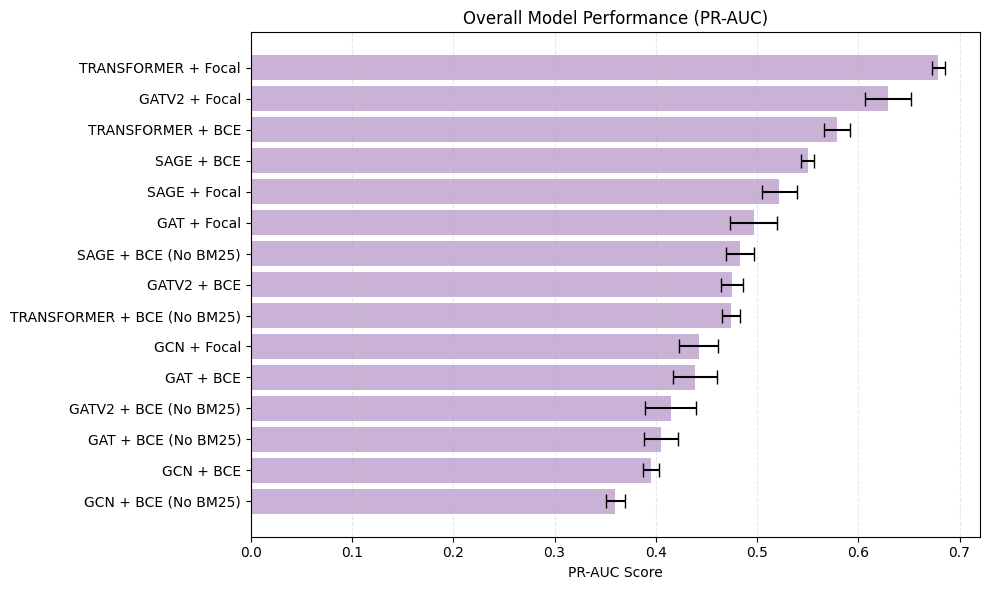

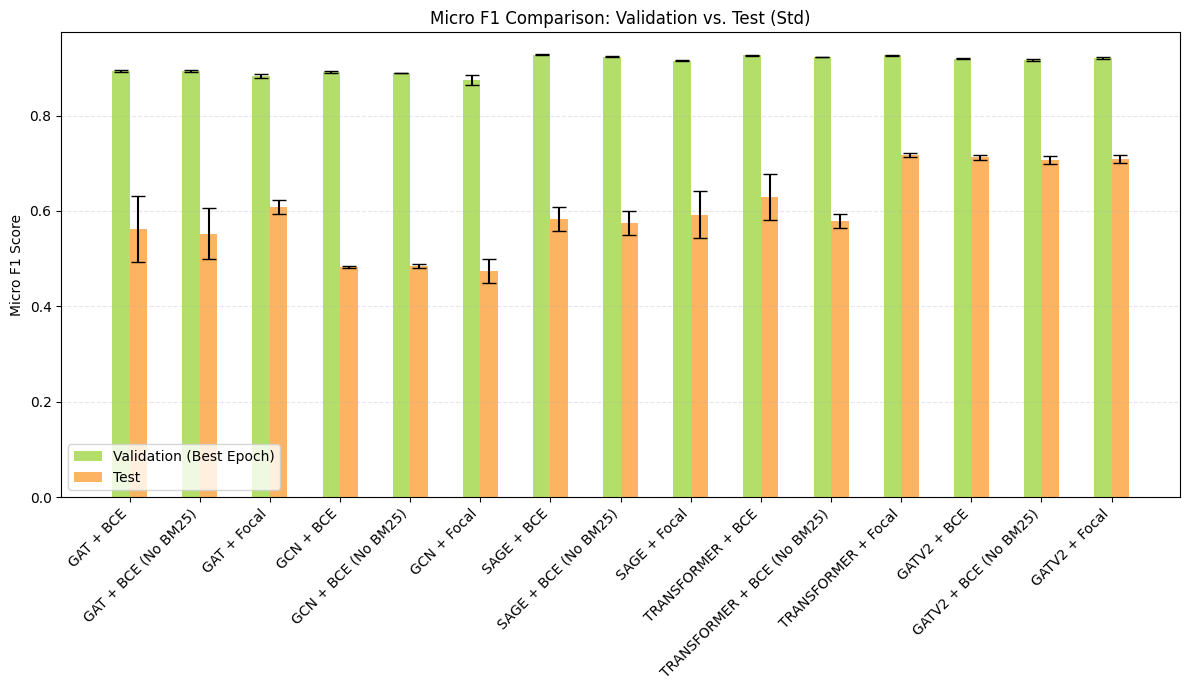

In [20]:
# --- PLOT 1: Overall PR-AUC Ranking ---
plt.figure(figsize=(10, 6))

# Sort by PR-AUC for ranking visual
df_sorted = df.sort_values('Test PR-AUC_mean', ascending=True)
y_pos = np.arange(len(df_sorted))

# Create Horizontal Bar Chart
plt.barh(y_pos, df_sorted['Test PR-AUC_mean'], xerr=df_sorted['Test PR-AUC_std'], capsize=5, color='#cab2d6')

plt.yticks(y_pos, df_sorted['Config'])
plt.xlabel('PR-AUC Score')
plt.title('Overall Model Performance (PR-AUC)')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('../../data/pr_auc_ranking.png')
plt.show()

# --- PLOT 2: Micro F1 Comparison (Val vs Test) ---
plt.figure(figsize=(12, 7))
x = np.arange(len(df))
width = 0.25  # Width of bars

# Bar 1: Validation
plt.bar(x - width/2, df['Val Micro_mean'], width, 
        yerr=df['Val Micro_std'], capsize=5, 
        label='Validation (Best Epoch)', color='#b3de69')

# Bar 3: Test Opt
plt.bar(x + width/2, df['Test Micro (Std)_mean'], width, 
        yerr=df['Test Micro (Std)_std'], capsize=5, 
        label='Test', color='#fdb462')

plt.xticks(x, df['Config'], rotation=45, ha='right')
plt.ylabel('Micro F1 Score')
plt.title('Micro F1 Comparison: Validation vs. Test (Std)')
plt.legend(loc='lower left') # Moved legend to avoid covering bars if needed
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('../../data/micro_f1_comparison.png')


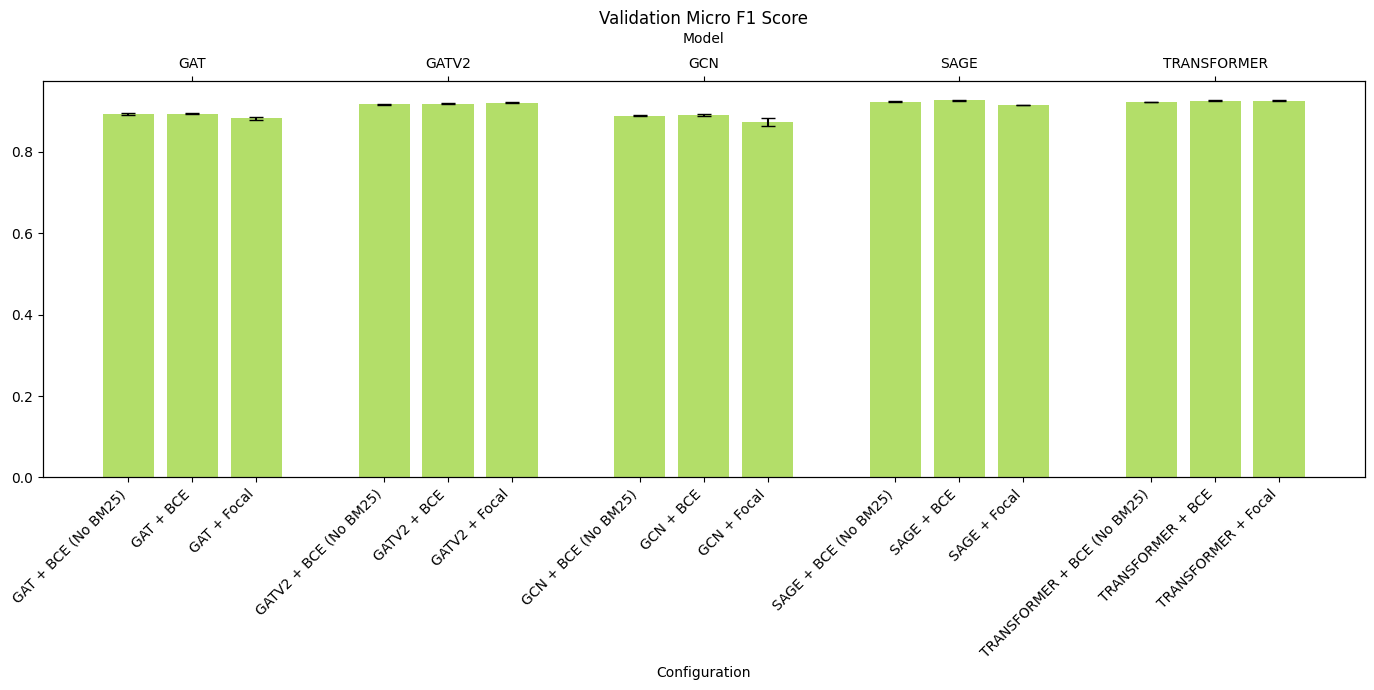

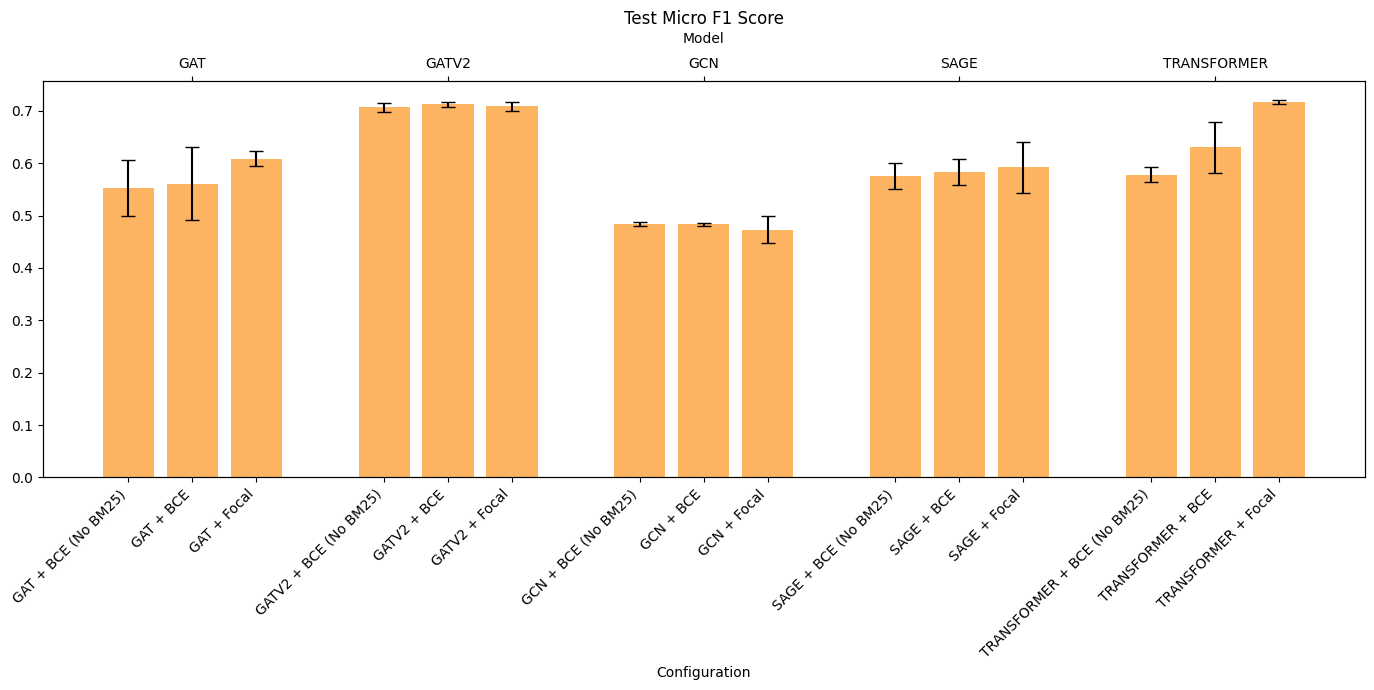

In [ ]:
# --- PLOT 2: Micro F1 Comparison (Val vs Test) ---
# Custom sorting: Group by model first, then by feature/loss type
# Within each model: (No BM25) -> BCE -> Focal
def get_sort_priority(config):
    """Returns priority: (No BM25)=0, BCE=1, Focal=2"""
    if '(No BM25)' in config:
        return 0
    elif 'BCE' in config:
        return 1
    elif 'Focal' in config:
        return 2
    else:
        return 3

# Create sort key column
df['_sort_priority'] = df['Config'].apply(get_sort_priority)
# Sort by Model first, then by priority within each model
df = df.sort_values(by=['Model', '_sort_priority'])
df = df.drop('_sort_priority', axis=1)

# Calculate group sizes and positions (grouped by model)
group_sizes = df.groupby('Model').size()
group_spacing = 1.0  # Space between groups

# Create x positions with no gaps within groups, spacing between groups
x_positions = []
group_centers = []
current_pos = 0

for model, size in group_sizes.items():
    # Bars within model group are consecutive (no gap)
    group_x = np.arange(size) + current_pos
    x_positions.extend(group_x)
    # Center of the group for top axis label
    group_center = current_pos + (size - 1) / 2
    group_centers.append(group_center)
    # Move to next group with spacing
    current_pos += size + group_spacing

x_positions = np.array(x_positions)
group_labels = list(group_sizes.index)  # Model names

# --- PLOT 2a: Validation Micro F1 ---
fig, ax = plt.subplots(figsize=(14, 7))
width = 0.8  # Width of bars

plt.bar(x_positions, df['Val Micro_mean'], width, 
        yerr=df['Val Micro_std'], capsize=5, 
        label='Validation (Best Epoch)', color='#b3de69')

# Bottom x-axis: individual config names
ax.set_xticks(x_positions)
ax.set_xticklabels(df['Config'], rotation=45, ha='right')
ax.set_xlabel('Configuration')

# Top x-axis: model names
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(group_centers)
ax2.set_xticklabels(group_labels)
ax2.set_xlabel('Model', labelpad=10)

plt.ylabel('Micro F1 Score')
plt.title('Validation Micro F1 Score')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('../../data/grp_validation_micro_f1.png')
plt.show()

# --- PLOT 2b: Test Micro F1 ---
fig, ax = plt.subplots(figsize=(14, 7))
width = 0.8  # Width of bars

plt.bar(x_positions, df['Test Micro (Std)_mean'], width, 
        yerr=df['Test Micro (Std)_std'], capsize=5, 
        label='Test', color='#fdb462')

# Bottom x-axis: individual config names
ax.set_xticks(x_positions)
ax.set_xticklabels(df['Config'], rotation=45, ha='right')
ax.set_xlabel('Configuration')

# Top x-axis: model names
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(group_centers)
ax2.set_xticklabels(group_labels)
ax2.set_xlabel('Model', labelpad=10)

plt.ylabel('Micro F1 Score')


plt.title('Test Micro F1 Score')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('../../data/grp_test_micro_f1.png')
plt.show()